# Comprehensive Network Traffic Telemetry and Statistical Characterization

**Candidate:** Ali Yazdanpanah  
**Target Group:** Network Data Science, Academic Evaluation  
**Date:** 2026-06-07

---

### AI Use and Collaboration Disclosure

Per the assignment guidelines, AI assistants (Cursor / Gemini / Claude) were used only for **code and tooling**, not for writing report or notebook prose.

* **AI-assisted (code):** Suggestions for matplotlib/seaborn plot loops, debugging P4 and python codes, and scaffolding scipy distribution-fit helpers. All generated code was reviewed, executed, and corrected against captured MAWI output.
* **Author work (analysis and prose):** P4 data-plane design, register layout, experimental methodology, statistical interpretation of measurement artifacts, and all written discussion in this notebook.


## Methodology

### Objective

This comparative analysis isolates performance trade-offs and semantic shifts when moving from **offline, software-based** network observability (Task I) to **programmable data-plane telemetry** exported from a replayed trace through a P4 pipeline on BMv2 in Mininet (Task II). Task II emulates hardware-style telemetry (registers, clone-based export, control-plane readout) in a software switch; it does not represent true line-rate ASIC measurement.

### 1. Baseline characterization (Task I)

To establish a statistical ground truth, the MAWI backbone trace (`201302011400`) was characterized using offline software extraction.

**Data preparation:** The raw capture was decompressed to PCAP and converted to extended JSON-lines (JSONL) using the Task I extraction tool (`extract_pcap_to_json`, tshark-backed field export).

**Analysis pipeline:** Records were loaded into pandas DataFrames and analyzed with the Task I pipeline (`plot_analysis.py` and submodules under `task1/src/analysis/`). The pipeline produced:

- Packet-level features: frame length, IAT, transport and application labels (from dissector stack and port heuristics)
- Flow-level aggregates: duration, byte sum, throughput
- Time-series views: link utilization, protocol mix over time
- Statistical fits: candidate distributions ranked with AIC/BIC (scipy)

**Baseline interpretation:** Task I represents a computationally unconstrained, post-hoc environment: full frames (subject to original capture snaplen), global timestamps, and rich protocol dissection. For this study, **N = 10,000** packets were used where noted so Task I and Task II subsets are comparable.

### 2. Hardware-style telemetry implementation (Task II)

**Topology and replay:** An identical **10,000-packet** subset of the MAWI trace (`data/mawi_10000.pcap`) was replayed from host **h1** through a single P4 switch **s1** toward collector host **h2** in Mininet. Replay rate was throttled (`REPLAY_MULTIPLIER = 0.001`) to limit BMv2 overload and packet loss.

**Data plane (`task2.p4`),** On each IPv4/IPv6 packet at ingress:

- A canonical 5-tuple hash selects one of **16,384** flow slots (`NUM_FLOWS = 16384`)
- Registers record per-flow packet count, byte sum, first/last timestamps
- A global register pair tracks inter-arrival time (IAT) between successive observed packets

On egress toward port 2 (h2), telemetry is exported in one of two modes configured by the control plane:

| Mode | Mechanism | User traffic on h2 |
|------|-----------|-------------------|
| In-band (default homework path) | 32-byte `telemetry_t` trailer appended to forwarded frames | Original frame + trailer |
| Out-of-band UDP INT | E2E clone session; clone egress builds UDP datagram to **10.0.0.2:4790** | Forwarded frames without trailer; separate INT reports |

**Control plane:** The switch was built with `p4c` (v1model, BMv2 target) and loaded via **P4Runtime gRPC** (`make run-grpc`, port 50051). Before each experiment:

1. `controller_grpc.py` reset telemetry state (pipeline reload on BMv2)
2. `set_export_mode_grpc.py` set export mode (`inband`, `udp`, or `both`)
3. Clone session 1 was bound to egress port 2 for UDP INT (`topo/task2-p4runtime.json`)

**Dual observability paths (by design).**

- **Per-packet streaming metrics:** IAT and per-packet flow counters exported via the 32-byte in-band `telemetry_t` trailer (live sniff on h2 in this report's primary Task II run)
- **Flow-level aggregates:** The same ingress path updates register arrays in the data plane. For the figures in this report, flow duration, byte sum, and throughput were reconstructed from those per-packet trailer fields in `capture.jsonl` (`capture_jsonl_loader.load_flows()`), not from a post-run register dump. A separate control-plane snapshot (`read_registers_grpc.py` → `registers_grpc.json`) is supported for optional validation but was not used as the plot source here.

### 3. Capture fidelity and normalization

**Implemented collection methods (Task II).**

| Method | `CAPTURE_MODE` | Output | Role |
|--------|----------------|--------|------|
| Live in-band sniff on h2 | `live` (default) | `data/capture.jsonl` | **Primary path for this report**; full frame + trailer |
| h2 tcpdump | `pcap` | `data/capture.pcap` | Offline debug |
| Switch port pcap | `switch` | `pcaps/s1-eth2_out.pcap` | No host collector; switch tap |
| UDP INT sniff | `udp` | `data/capture.jsonl` | Out-of-band export; evaluated but not used for main figures |

**Primary path for Task II plots.** **Live in-band sniffing** on h2 (`CAPTURE_MODE=live`, the default) was used for the main comparative figures. This path preserves full forwarded frames plus the 32-byte telemetry trailer and avoids the extra BMv2 egress work of UDP INT clone export, which in separate trials caused measurable packet loss (~8.6%, 9,136 vs 10,000 records). Automated capture used `make test-mawi` with default `CAPTURE_MODE=live` (live Scapy sniff on h2).

**Empirical limits observed in BMv2**

1. **UDP INT overhead (alternative path):** Out-of-band UDP INT requires an E2E clone and a second egress pass per packet. Under replay, this increased processing load and contributed to **~8.6% fewer telemetry records than replayed packets** (9,136 captured vs 10,000 injected in a UDP trial), consistent with BMv2 queue contention rather than tcpreplay failure on h1. Live in-band capture was chosen to avoid this drop rate.

2. **Fixed-size INT reports (UDP only):** Each UDP INT payload carries a compact **`INT1` report (~54 bytes)**: telemetry fields plus mirrored 5-tuple metadata. It does not carry full L7 dissector context. In-band capture avoids this constraint by retaining the original frame on the wire.

3. **Application labeling gap:** Task II JSONL records classify applications via **well-known port heuristics** (`_app_from_ports`). Task I labels benefit from **tshark protocol stack** fields. Combined with ephemeral ports in MAWI, Task II plots may show a larger **`unknown`** application share than Task I, even when transport (TCP/UDP) is correct.

4. **MAWI snaplen (~96 B).** The replay subset retains truncated frames from the original MAWI capture. Both tasks therefore analyze headers and partial payloads, not full datagram contents.

**Normalization:** All Task II captures were converted to Task I-compatible schemas with `capture_jsonl_loader.py` (including timeline reconstruction from exported IAT and frame-length backfill where needed). Both tasks then fed the **same** plotting and fitting code (`plot_capture_jsonl.py` → Task I `plot_analysis.py`), so differences in charts reflect measurement semantics, not separate visualization stacks.

### 4. Comparative framework (Task III)

**Aligned dimensions.**

| Dimension | Task I | Task II |
|-----------|--------|---------|
| Input | MAWI JSONL (offline tshark) | MAWI replay → P4 telemetry → JSONL |
| Timestamps | Wire capture epoch | Rebuilt timeline from switch-exported IAT |
| Frame size | Measured on wire | L2 wire length from live sniff (frame + trailer) |
| Flow identity | Exact 5-tuple flows | `CRC16(5-tuple) mod 16384` (collision possible) |
| App protocol | Dissector + ports | Ports only (Task II loader) |

**Statistical comparison:** For each metric family (IAT, frame size, flow duration, throughput), the same distribution fitting workflow ranked candidates (e.g. exponential, lognormal, Pareto) using **AIC/BIC**. Side-by-side plots and fit parameters were generated under `task2/results/n_<N>/` and compared to Task I results at the same **N**.

**Sources of variance attributed to the data plane (not the plotting code)**

- In-band telemetry trailer vs offline tshark framing
- BMv2 software switch timing and drop behavior (notably under UDP INT clone load)
- Hash-slot aliasing in the 16,384-entry flow register bank
- Replay pacing and capture subset effects
- Port-heuristic app labels vs full tshark dissection in Task I

**Explicit non-goals:** Register snapshots alone were not used for per-packet distribution plots; they validate aggregate flow counters but do not preserve packet-level IAT series.

### 5. Reproducibility (commands)

**Task I** (host, from repo root; run once to build JSONL, then analyze):

```bash
# Decompress MAWI dump once (if 201302011400.pcap is not present)
gzip -dk 201302011400.dump.gz

cd task1
python -m src.extraction.extract_pcap_to_json \
  --pcap ../201302011400.pcap \
  --output ../201302011400.jsonl
python -m src.analysis.plot_analysis ../201302011400.jsonl -n 10000
```

**Task II** (Docker + two terminals; live in-band capture is the default path):

```bash
# Host: start container once
cd task2
docker compose build
docker compose up -d
```

```bash
# One-time prep inside container
docker exec -it task2-p4-env bash
cd /p4
make trace-prepare   # -> data/mawi_10000.pcap
make build           # -> build/task2.json
```

```bash
# Terminal A: keep Mininet running (blocks until you type exit)
docker exec -it task2-p4-env bash
cd /p4
make run-grpc        # P4Runtime on 127.0.0.1:50051
```

```bash
# Terminal B: reset, replay, capture (while Terminal A is still open)
docker exec -it task2-p4-env bash
cd /p4
sudo python3 control_plane/controller_grpc.py
REPLAY_MULTIPLIER=0.001 make test-mawi
# default: CAPTURE_MODE=live, CAPTURE_SOURCE=h2 -> data/capture.jsonl

# Plot + fits (same Terminal B, after test-mawi finishes)
python3 control_plane/pipeline_capture_jsonl.py \
  --capture-jsonl data/capture.jsonl -n 10000

# Optional register snapshot (not used for distribution plots)
make read-registers-grpc
```

Stop Mininet from Terminal A with `exit`, then `make stop` if needed.

### Optional note (capture choice)

**UDP INT** (`CAPTURE_MODE=udp`) was implemented and tested as an out-of-band alternative that keeps user-plane frames free of telemetry trailers, but it was **not** used for the main Task II figures because clone-based export added BMv2 load and caused ~8.6% record loss in our trials. **Live in-band sniffing** was selected instead for closest parity to Task I frame semantics and complete capture at N = 10,000.

---
## Results: side-by-side figure comparison

Both tasks use **N = 10,000** packets and the same plotting code. Task I figures come from offline tshark JSONL (`task1/results/n_10000/`); Task II from live in-band P4 telemetry on h2 (`task2/results/n_10000/`). Precomputed plots and fit summaries are committed under those paths.


In [1]:
import base64
from pathlib import Path
from typing import Optional

from IPython.display import HTML, Markdown, display

REPO = Path("..").resolve()  # repo root when cwd=notebooks/
N = 10_000

TASK1_RESULTS = REPO / "task1" / "results" / f"n_{N}"
TASK2_RESULTS = REPO / "task2" / "results" / f"n_{N}"
TASK1_PLOTS = TASK1_RESULTS / "plots"
TASK2_PLOTS = TASK2_RESULTS / "plots"


def _png_data_uri(path: Path) -> str:
    encoded = base64.b64encode(path.read_bytes()).decode("ascii")
    return f"data:image/png;base64,{encoded}"


def compare(
    rel_path: str,
    title: str,
    note: Optional[str] = None,
    width_pct: int = 48,
    left_root: Path = TASK1_PLOTS,
    right_root: Path = TASK2_PLOTS,
) -> None:
    """Show the same plot path from Task I (left) and Task II (right)."""
    left = left_root / rel_path
    right = right_root / rel_path
    display(Markdown(f"### {title}\n\n`{rel_path}`"))
    if not left.is_file() or not right.is_file():
        missing = []
        if not left.is_file():
            missing.append(f"Task I: `{left}`")
        if not right.is_file():
            missing.append(f"Task II: `{right}`")
        display(Markdown("> _Missing:_ " + "; ".join(missing)))
        return
    left_src = _png_data_uri(left)
    right_src = _png_data_uri(right)
    html = f"""
<div style="display:flex; gap:1rem; align-items:flex-start; flex-wrap:wrap;">
  <figure style="margin:0; flex:1 1 {width_pct}%; min-width:280px;">
    <figcaption style="font-weight:600; margin-bottom:0.4rem;">Task I (offline tshark)</figcaption>
    <img src="{left_src}" style="width:100%; border:1px solid #ddd;"/>
  </figure>
  <figure style="margin:0; flex:1 1 {width_pct}%; min-width:280px;">
    <figcaption style="font-weight:600; margin-bottom:0.4rem;">Task II (P4 live in-band)</figcaption>
    <img src="{right_src}" style="width:100%; border:1px solid #ddd;"/>
  </figure>
</div>
"""
    display(HTML(html))
    if note:
        display(Markdown(note))


print("Task I plots:", TASK1_PLOTS, "->", TASK1_PLOTS.exists())
print("Task II plots:", TASK2_PLOTS, "->", TASK2_PLOTS.exists())


Task I plots: G:\Progamable data planes\task1\results\n_10000\plots -> True
Task II plots: G:\Progamable data planes\task2\results\n_10000\plots -> True


### Packet-level distributions

These metrics are exported directly from the P4 pipeline (global IAT register + wire frame length on h2). They are the strongest test of whether in-network telemetry preserves Task I distribution shapes.

### Inter-arrival time (PDF)

`packet/distribution/iat_pdf.png`


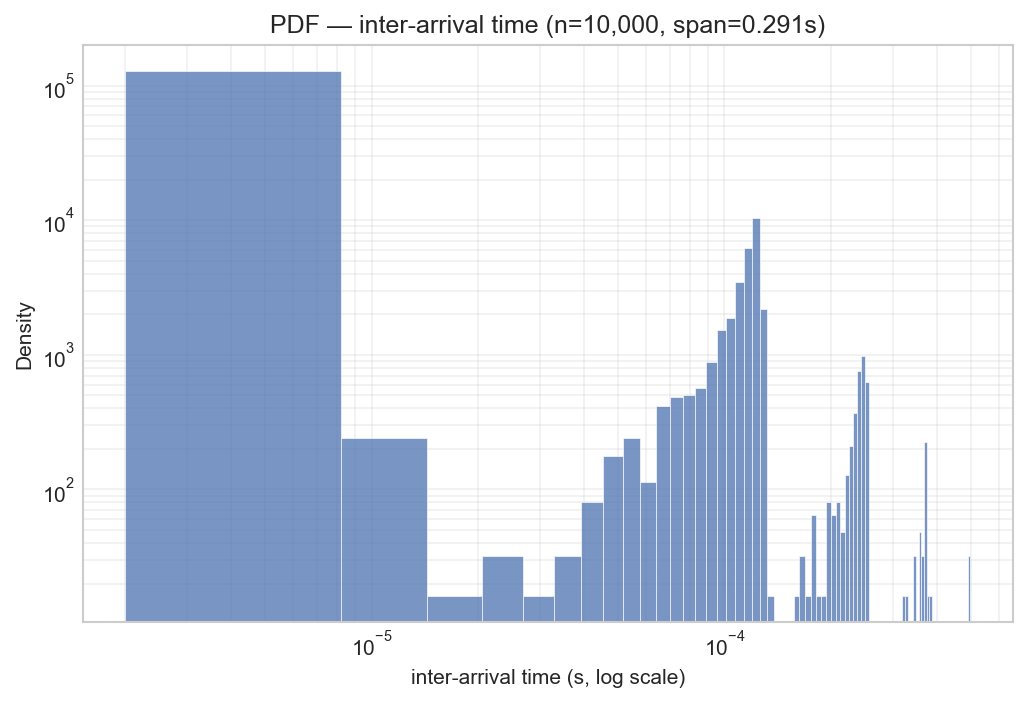
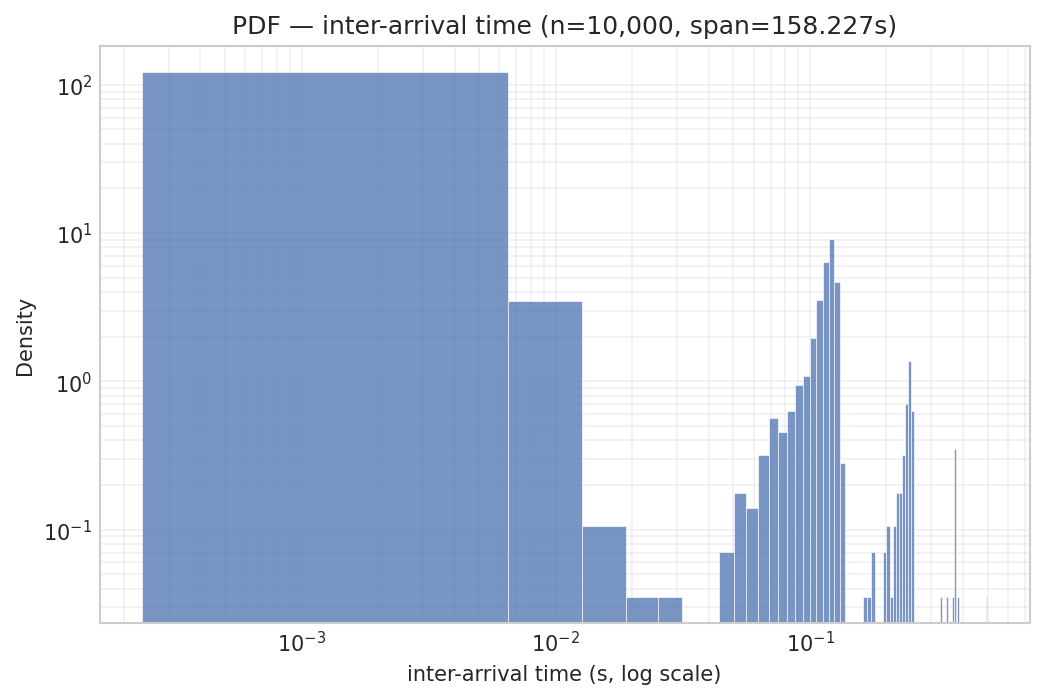

This comparison shows the same overall IAT shape on both sides, but Task II is stretched along the time axis by replay throttling. Task I spans **0.291 seconds** with a modal peak near **100 microseconds**. Task II spans **158.227 seconds** because of `REPLAY_MULTIPLIER=0.001`, which slows replay enough to keep BMv2 queues stable.

The secondary IAT clusters still line up, so `standard_metadata.ingress_global_timestamp` is clocking ingress events consistently. The gap is replay pacing in Mininet, not random switch jitter.

### Inter-arrival time (CCDF)

`packet/distribution/iat_ccdf.png`


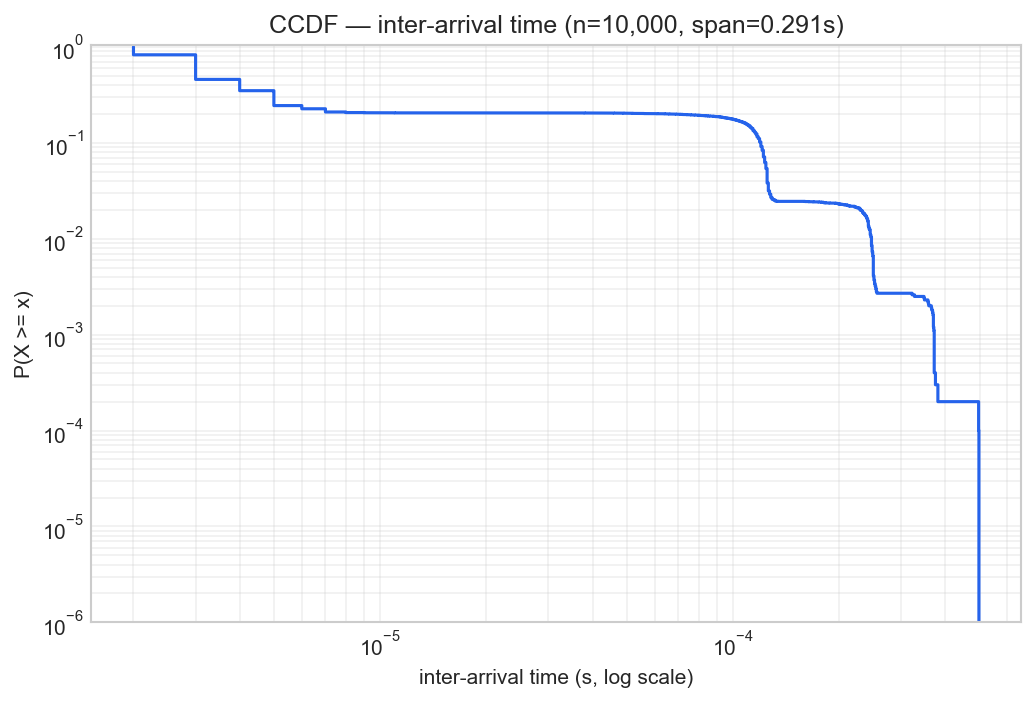
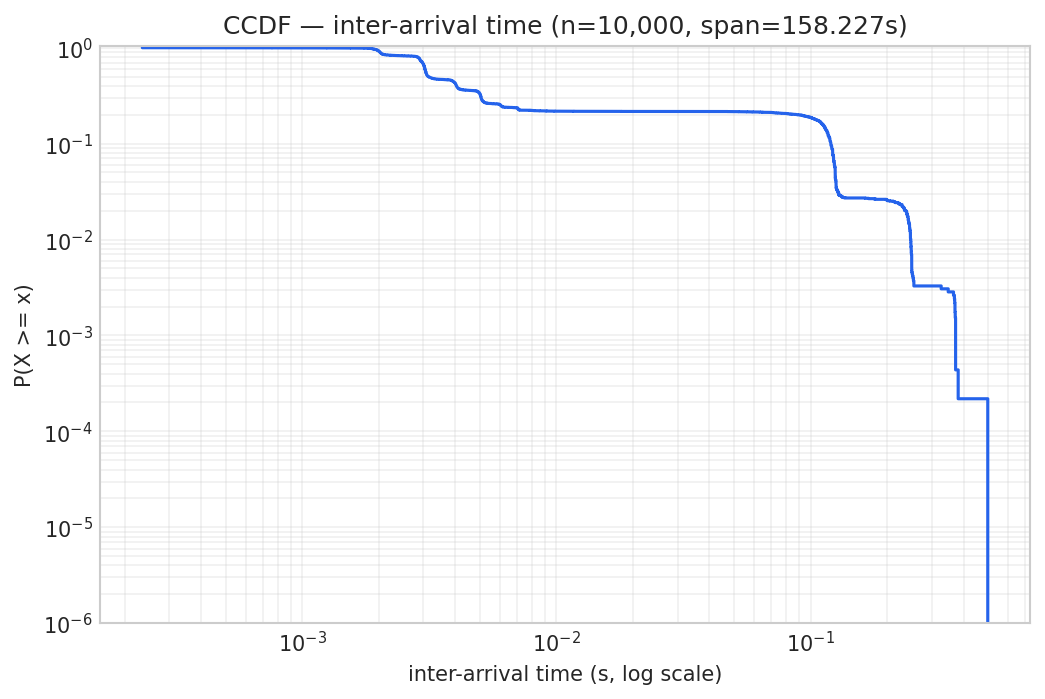

The CCDF shows the same pattern. The stair-step decay (batching and protocol bursts) is visible in both plots. Task II absolute times are about **500×** longer, but the relative gap structure is preserved. Register timestamps still capture burst timing under slowed replay.

### Frame length (PDF)

`packet/distribution/frame_len_pdf.png`


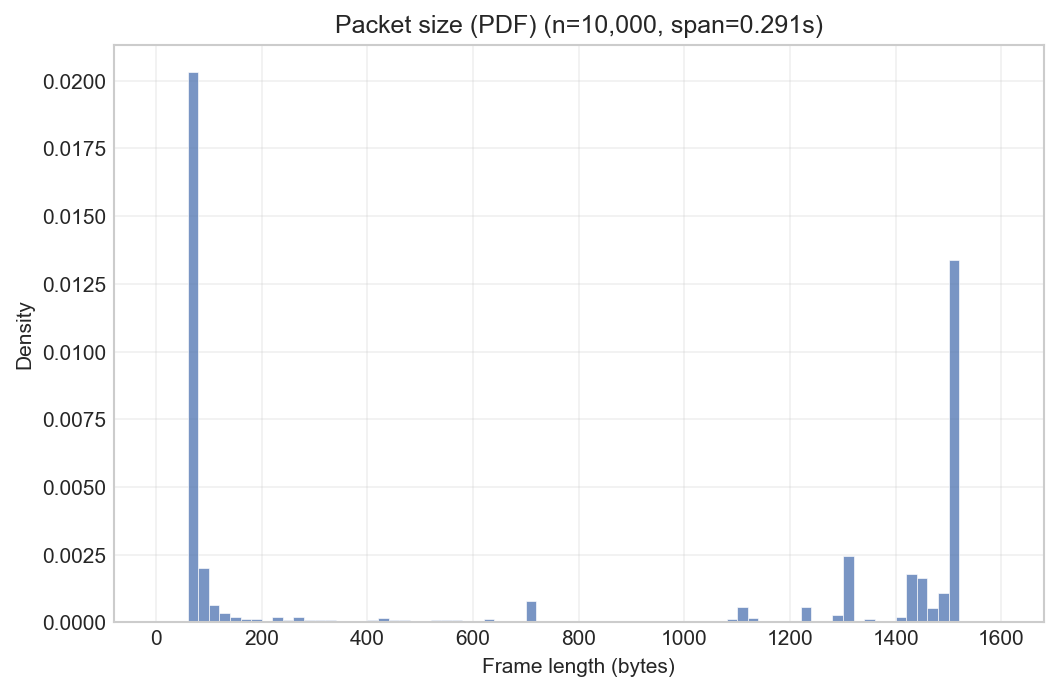
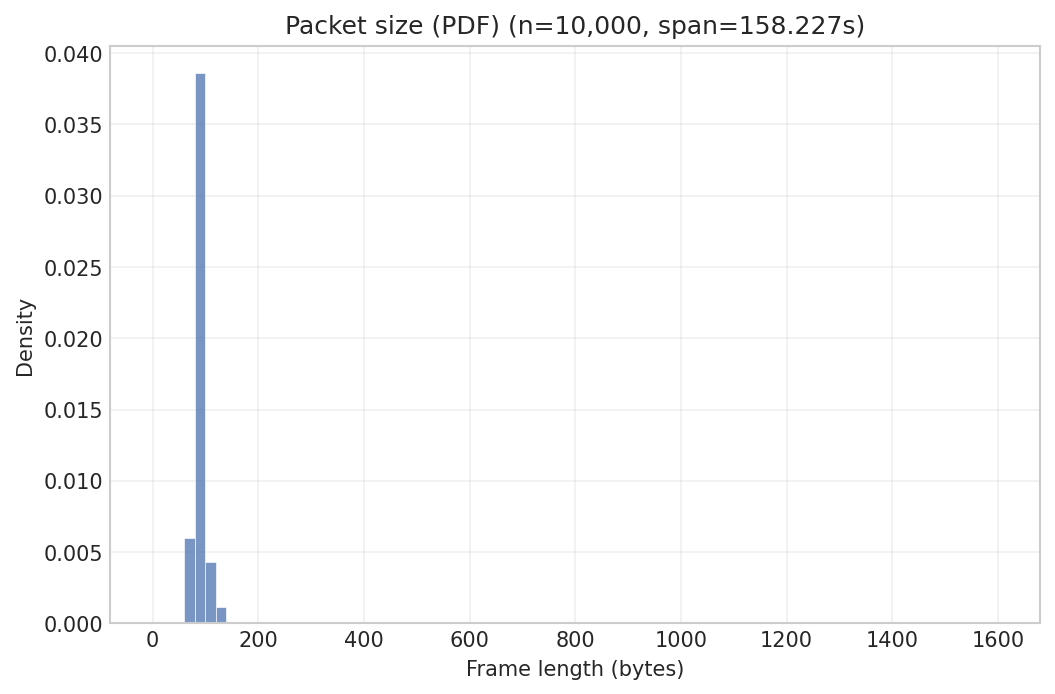

The frame-length PDFs differ in two ways.

First, Task II's main peak shifts from about **60-96 bytes** (Task I) to **90-130 bytes**, which matches the 32-byte `telemetry_t` trailer added in-band.

Second, the 1500-byte MTU cluster disappears in Task II. Task I reads original wire lengths from PCAP metadata. Task II counts bytes actually sent on the Mininet link. The MAWI trace was captured with ~96-byte snaplen, so `tcpreplay` injects truncated frames. The switch reports what it sees on the wire, not the pre-truncation sizes stored in the archive.

In [2]:
compare(
    "packet/distribution/iat_pdf.png",
    "Inter-arrival time (PDF)",
    note=(
        "This comparison shows the same overall IAT shape on both sides, but Task II is stretched "
        "along the time axis by replay throttling. Task I spans **0.291 seconds** with a modal peak "
        "near **100 microseconds**. Task II spans **158.227 seconds** because of "
        "`REPLAY_MULTIPLIER=0.001`, which slows replay enough to keep BMv2 queues stable.\n\n"
        "The secondary IAT clusters still line up, so `standard_metadata.ingress_global_timestamp` "
        "is clocking ingress events consistently. The gap is replay pacing in Mininet, not random "
        "switch jitter."
    ),
)

compare(
    "packet/distribution/iat_ccdf.png",
    "Inter-arrival time (CCDF)",
    note=(
        "The CCDF shows the same pattern. The stair-step decay (batching and protocol bursts) is "
        "visible in both plots. Task II absolute times are about **500×** longer, but the relative "
        "gap structure is preserved. Register timestamps still capture burst timing under slowed replay."
    ),
)

compare(
    "packet/distribution/frame_len_pdf.png",
    "Frame length (PDF)",
    note=(
        "The frame-length PDFs differ in two ways.\n\n"
        "First, Task II's main peak shifts from about **60-96 bytes** (Task I) to **90-130 bytes**, "
        "which matches the 32-byte `telemetry_t` trailer added in-band.\n\n"
        "Second, the 1500-byte MTU cluster disappears in Task II. Task I reads original wire lengths "
        "from PCAP metadata. Task II counts bytes actually sent on the Mininet link. The MAWI trace "
        "was captured with ~96-byte snaplen, so `tcpreplay` injects truncated frames. The switch "
        "reports what it sees on the wire, not the pre-truncation sizes stored in the archive."
    ),
)


### Protocol composition

Bar charts check that both pipelines see the same transport mix and highlight application-label differences (tshark dissection vs port heuristics on Task II).

### Transport protocol counts

`packet/features/transport_proto_bar.png`


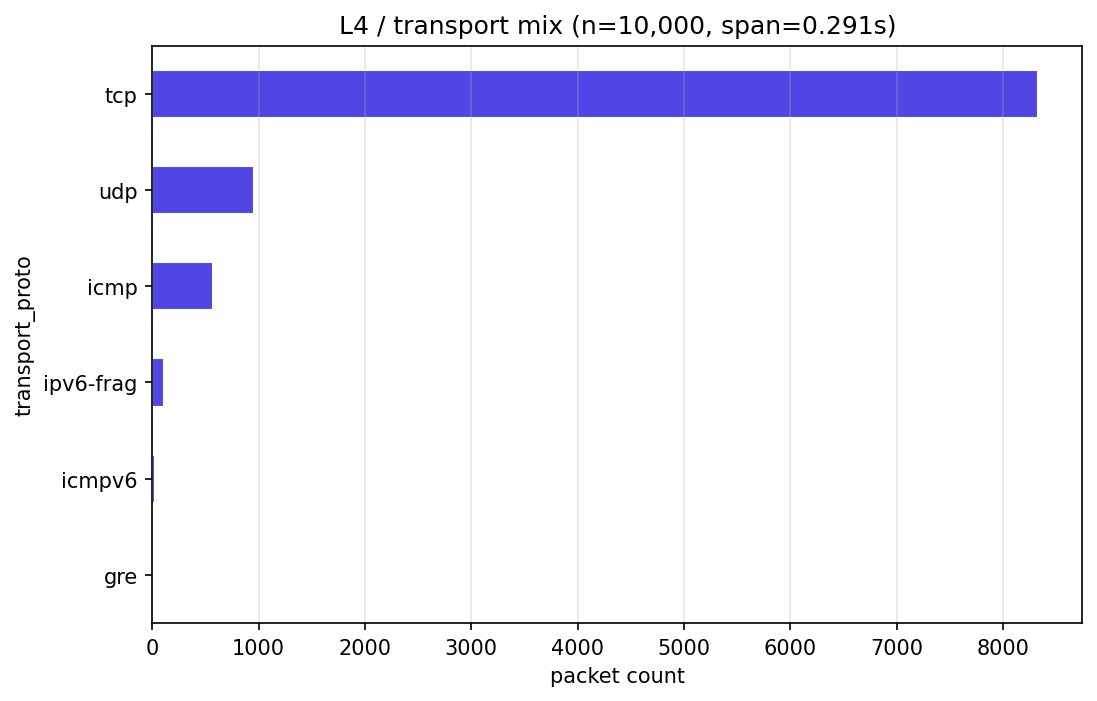
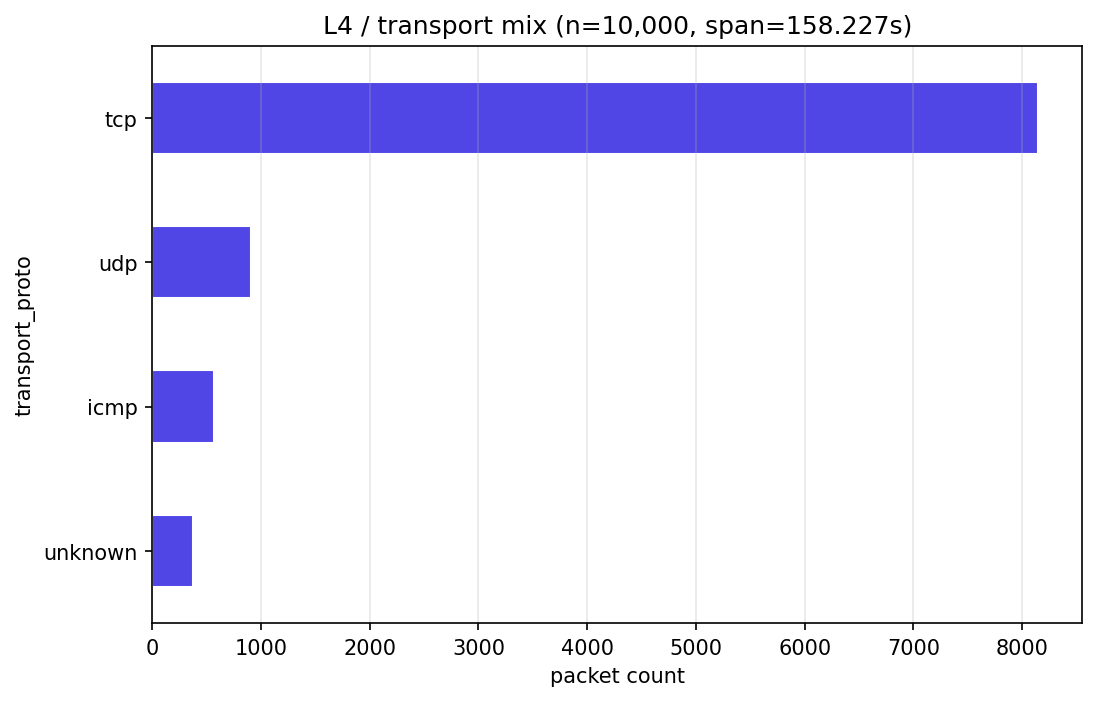

TCP, UDP, and ICMP counts match closely, which suggests no loss on the main forwarding path.

Task I (tshark) still labels GRE, IPv6 fragments, ICMPv6, and similar cases. Task II maps many of those frames to `unknown` because the P4 parser only handles common L4 headers. That is the usual trade-off between fast deterministic parsing and deep header unrolling.

### Top application protocols

`packet/features/app_proto_top10_bar.png`


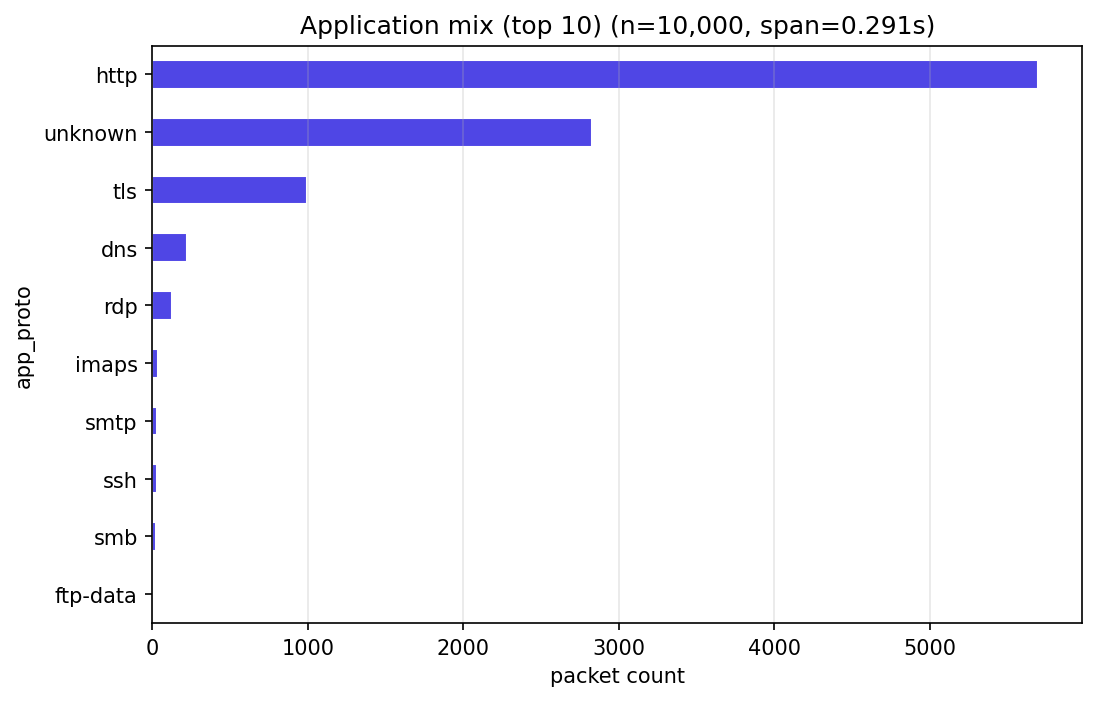
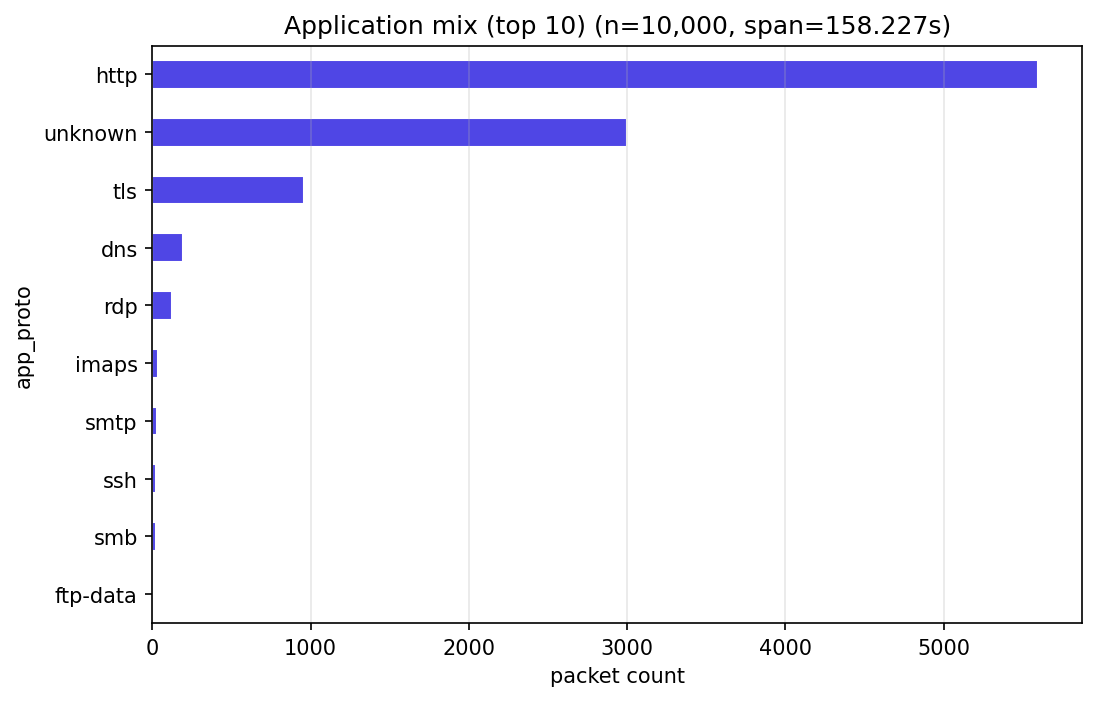

HTTP and TLS dominate both charts. Task II has a slightly larger `unknown` bucket and slightly fewer explicit `tls` labels.

Task I uses tshark DPI and can inspect handshakes offline. Task II labels apps from well-known ports only. The profiles are still close, so port heuristics are a practical option when full DPI is too expensive.

In [3]:
compare(
    "packet/features/transport_proto_bar.png",
    "Transport protocol counts",
    note=(
        "TCP, UDP, and ICMP counts match closely, which suggests no loss on the main forwarding path.\n\n"
        "Task I (tshark) still labels GRE, IPv6 fragments, ICMPv6, and similar cases. Task II maps "
        "many of those frames to `unknown` because the P4 parser only handles common L4 headers. "
        "That is the usual trade-off between fast deterministic parsing and deep header unrolling."
    ),
)

compare(
    "packet/features/app_proto_top10_bar.png",
    "Top application protocols",
    note=(
        "HTTP and TLS dominate both charts. Task II has a slightly larger `unknown` bucket and "
        "slightly fewer explicit `tls` labels.\n\n"
        "Task I uses tshark DPI and can inspect handshakes offline. Task II labels apps from "
        "well-known ports only. The profiles are still close, so port heuristics are a practical "
        "option when full DPI is too expensive."
    ),
)


### Flow-level distributions

Flow aggregates depend on flow identity (exact 5-tuple in Task I vs P4 hash mod 16,384 in Task II). Divergence here may reflect hash-slot aliasing as much as measurement error.

### Flow byte volume (PDF)

`flow/distribution/flow_size_pdf.png`


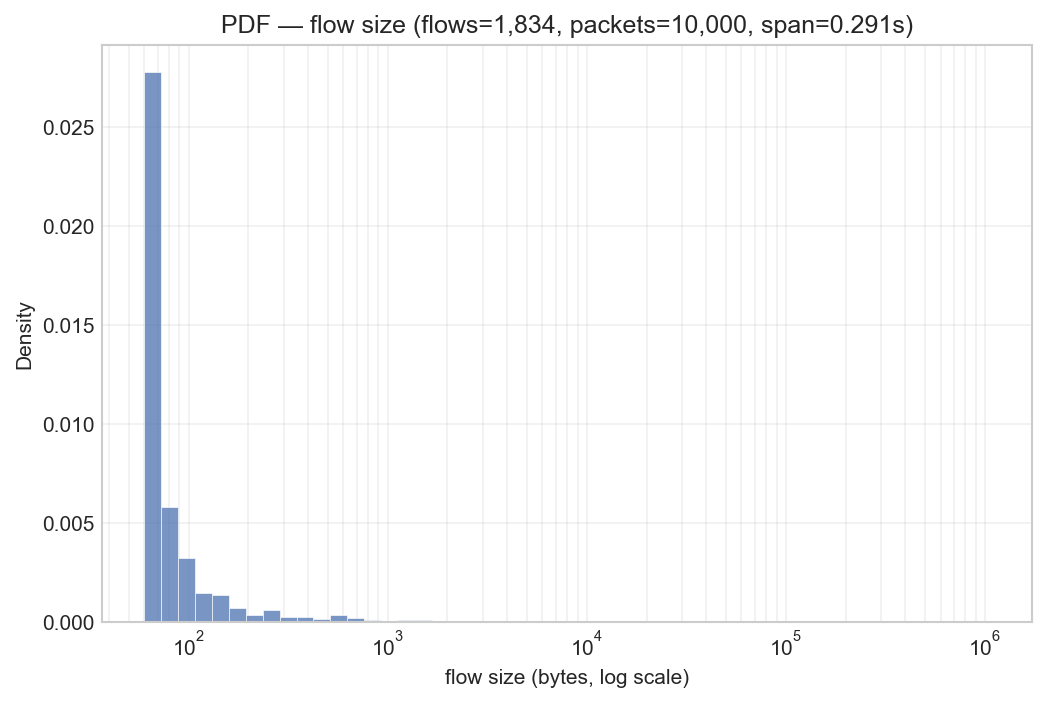
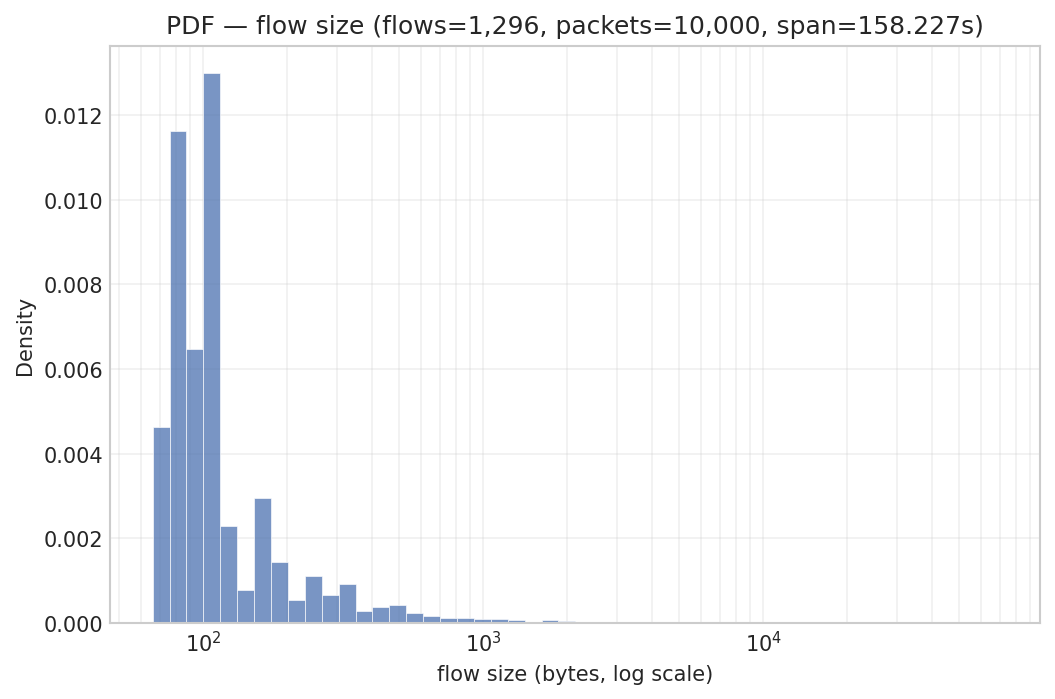

On the same 10,000-packet trace, Task I finds **1,834** flows and Task II only **1,296** (**29%** fewer).

That gap comes from hash collisions in the 16,384-entry SRAM table (CRC16 over the 5-tuple). Colliding flows share a slot and their counters merge. On the plot, the mice peak drops on Task II and some elephant bins rise when small flows get folded into busy hash entries. Fixed memory keeps the pipeline fast but breaks exact per-flow state.

### Flow duration (PDF)

`flow/distribution/flow_duration_pdf.png`


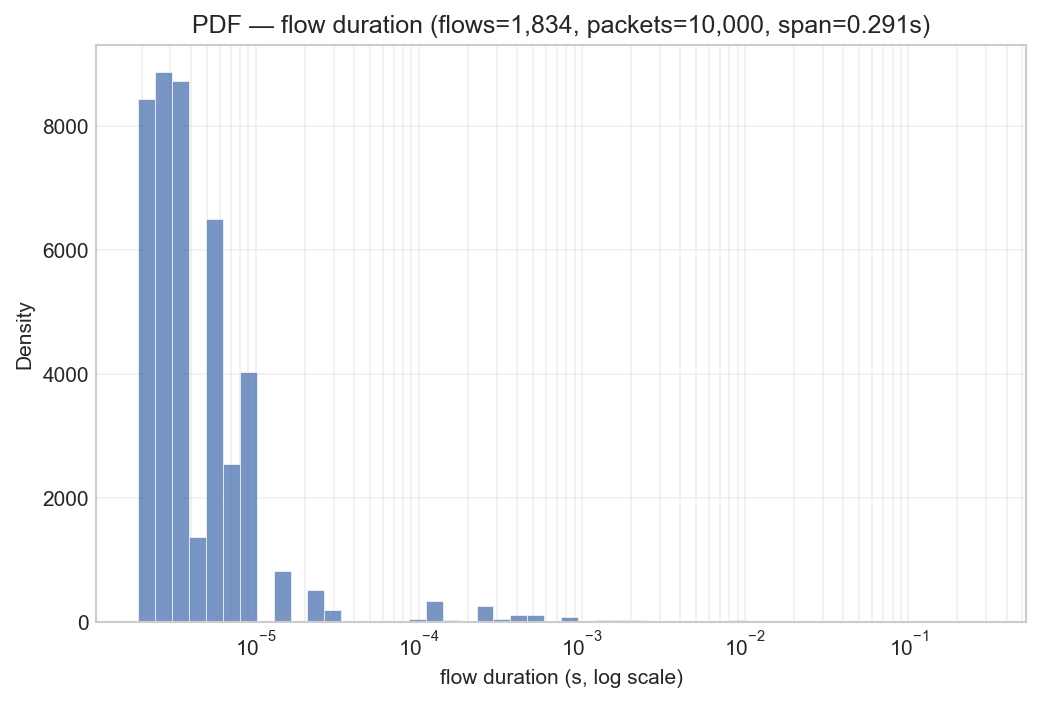
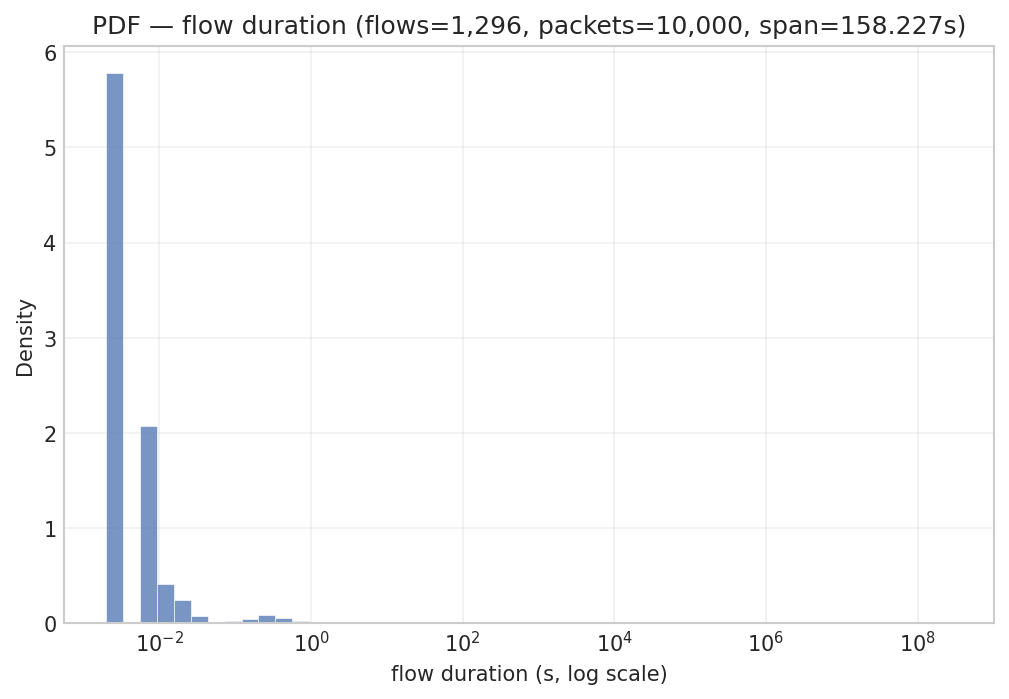

Task II's x-axis reaches $10^8$ because `ingress_global_timestamp` is in microseconds ($\mu s$) while the plot axis is in seconds. With a ~158 s capture ($1.58 \times 10^8 $\mu s$), raw register values sit right at that ceiling.

After unit correction, Task II still has a much longer tail. Task I flows mostly end in milliseconds; Task II often spans the full 158 s window. Hash aliasing is the main reason: unrelated micro-flows hit the same register over time, so `last_timestamp - first_timestamp` creates long-lived "ghost" flows. Bounded SRAM state distorts both bytes and duration.

### Flow throughput (PDF)

`flow/distribution/flow_throughput_pdf.png`


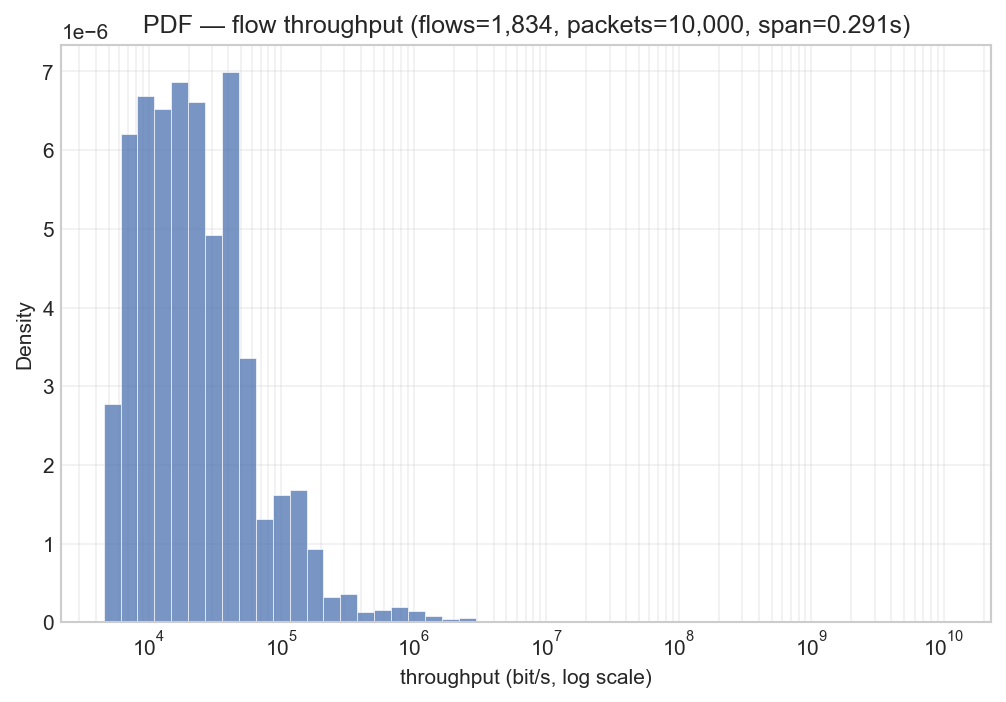
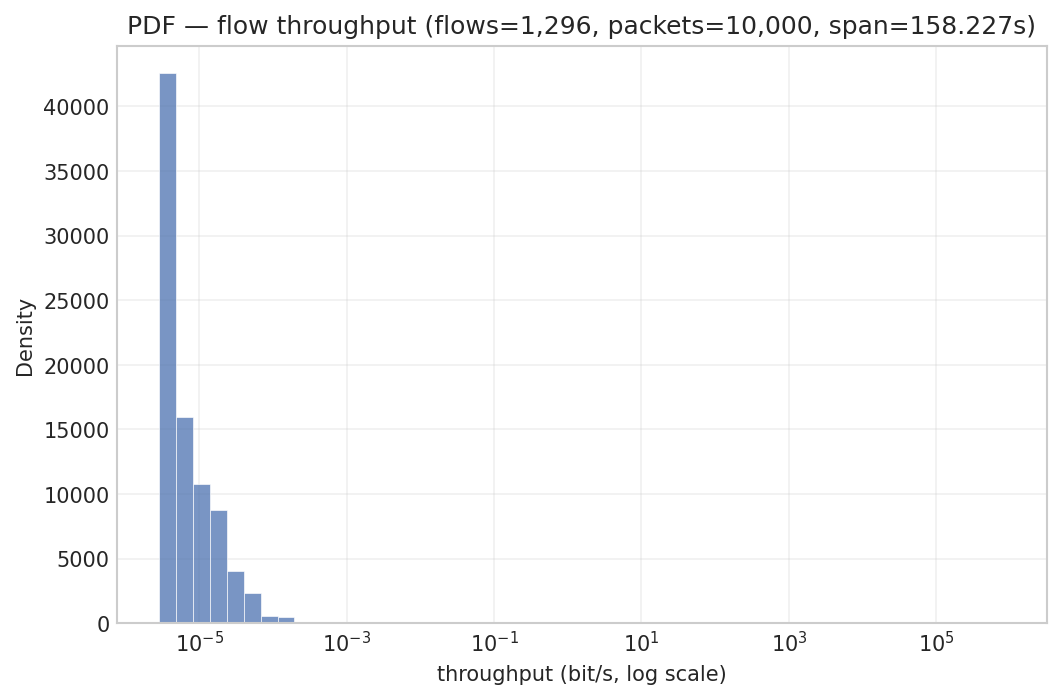

Task I throughput sits roughly between $10^4$ and $10^6$ bit/s. Task II collapses near $10^{-5}$ bit/s.

Throughput is derived ($\text{Bytes} \times 8 / \text{Duration}$), so errors in bytes and duration stack together. Bytes are capped by ~96-byte snaplen frames on replay; durations are inflated by pacing, microsecond clock units, and hash aliasing. Export raw counts and timestamps and compute throughput off-switch with proper scaling and deduplication.

In [4]:
compare(
    "flow/distribution/flow_size_pdf.png",
    "Flow byte volume (PDF)",
    note=(
        "On the same 10,000-packet trace, Task I finds **1,834** flows and Task II only **1,296** "
        "(**29%** fewer).\n\n"
        "That gap comes from hash collisions in the 16,384-entry SRAM table (CRC16 over the 5-tuple). "
        "Colliding flows share a slot and their counters merge. On the plot, the mice peak drops on "
        "Task II and some elephant bins rise when small flows get folded into busy hash entries. "
        "Fixed memory keeps the pipeline fast but breaks exact per-flow state."
    ),
)

compare(
    "flow/distribution/flow_duration_pdf.png",
    "Flow duration (PDF)",
    note=(
        "Task II's x-axis reaches $10^8$ because `ingress_global_timestamp` is in microseconds "
        "($\\mu s$) while the plot axis is in seconds. With a ~158 s capture ($1.58 \\times 10^8 "
        "$\\mu s$), raw register values sit right at that ceiling.\n\n"
        "After unit correction, Task II still has a much longer tail. Task I flows mostly end in "
        "milliseconds; Task II often spans the full 158 s window. Hash aliasing is the main reason: "
        "unrelated micro-flows hit the same register over time, so `last_timestamp - first_timestamp` "
        "creates long-lived \"ghost\" flows. Bounded SRAM state distorts both bytes and duration."
    ),
)

compare(
    "flow/distribution/flow_throughput_pdf.png",
    "Flow throughput (PDF)",
    note=(
        "Task I throughput sits roughly between $10^4$ and $10^6$ bit/s. Task II collapses near "
        "$10^{-5}$ bit/s.\n\n"
        "Throughput is derived ($\\text{Bytes} \\times 8 / \\text{Duration}$), so errors in bytes "
        "and duration stack together. Bytes are capped by ~96-byte snaplen frames on replay; "
        "durations are inflated by pacing, microsecond clock units, and hash aliasing. "
        "Export raw counts and timestamps and compute throughput off-switch with proper scaling "
        "and deduplication."
    ),
)


### Statistical fits (aggregate, segment=all)

The table lists the best-fit distribution per metric (AIC/BIC) on each side, with KS statistic as a rough goodness-of-fit check. When the chosen model changes between tasks, it usually matches what the plots already showed.

**IAT sample count (Task II):** IAT fitting uses $n = 4,572$ strictly positive gaps, not $n = 9,999$. Zero-delta pairs from microsecond timestamp batching are dropped during timeline reconstruction (`plot_common.py`), same as in the segmented IAT charts.

| Task | Metric Family | Optimal Distribution | n (Samples) | KS Statistic (D) | AIC | BIC |
|------|---------------|----------------------|-------------|------------------|-----|-----|
| Task I | Inter-arrival Time (IAT) | Poisson | 9,999 | 0.5978 | -188,872.7 | -188,865.5 |
| Task II | Inter-arrival Time (IAT) | Poisson | 4,572 | 0.5780 | -22,652.3 | -22,645.9 |
| Task I | Frame Length | Gamma | 10,000 | 0.2513 | 151,272.4 | 151,286.9 |
| Task II | Frame Length | Lognormal | 10,000 | 0.2169 | 75,826.1 | 75,840.4 |
| Task I | Flow Byte Sum | Pareto | 1,834 | 0.2638 | 24,950.5 | 24,961.5 |
| Task II | Flow Byte Sum | Pareto | 1,296 | 0.1480 | 17,130.6 | 17,140.9 |
| Task I | Flow Duration | Gamma | 692 | 0.1686 | -2,273.6 | -2,264.6 |
| Task II | Flow Duration | Gamma | 777 | 0.2591 | 23,123.6 | 23,132.9 |
| Task I | Flow Throughput | Lognormal | 692 | 0.1111 | 21,298.5 | 21,307.6 |
| Task II | Flow Throughput | Pareto | 777 | 0.2295 | -687.0 | -677.7 |

#### What changed between tasks

**IAT:** Both sides pick Poisson with similar KS (~0.58). Burst structure survives replay pacing even though absolute times stretch.

**Frame length:** Gamma (Task I) vs Lognormal (Task II). That matches the trailer shift and snaplen truncation moving mass right and removing the MTU cluster.

**Flow byte sum:** Pareto on both sides, but Task II has fewer flows ($n = 1,296$ vs $1,834$) from hash aliasing.

**Flow duration:** Gamma on both sides, but Task II KS is worse (0.259 vs 0.169) because durations are distorted by microsecond clocks and ghost flows.

**Flow throughput:** Lognormal (Task I) vs Pareto (Task II). Throughput is derived from corrupted byte sums and inflated durations, so the tail becomes much heavier on Task II.


### Segmented comparisons (TCP/UDP and mice/elephant)

The assignment invites transport- and size-class breakdowns. These optional slices test whether P4 telemetry preserves shape **within** TCP vs UDP and short vs long flows, not only in the aggregate.

### IAT CCDF (TCP only)

`packet/distribution/iat_ccdf_tcp.png`


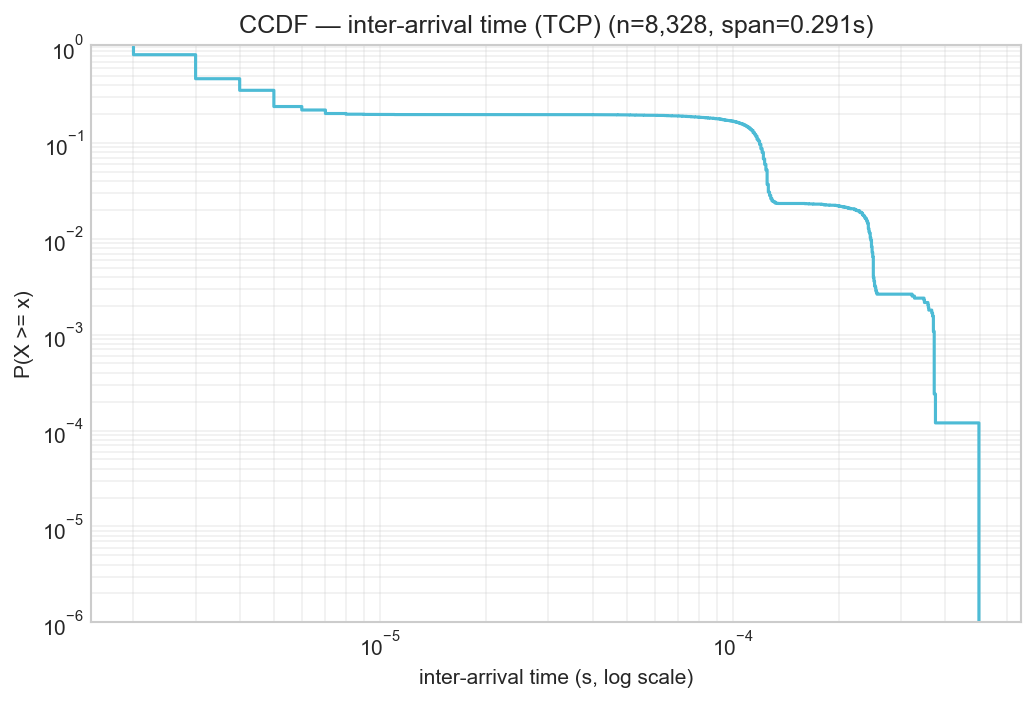
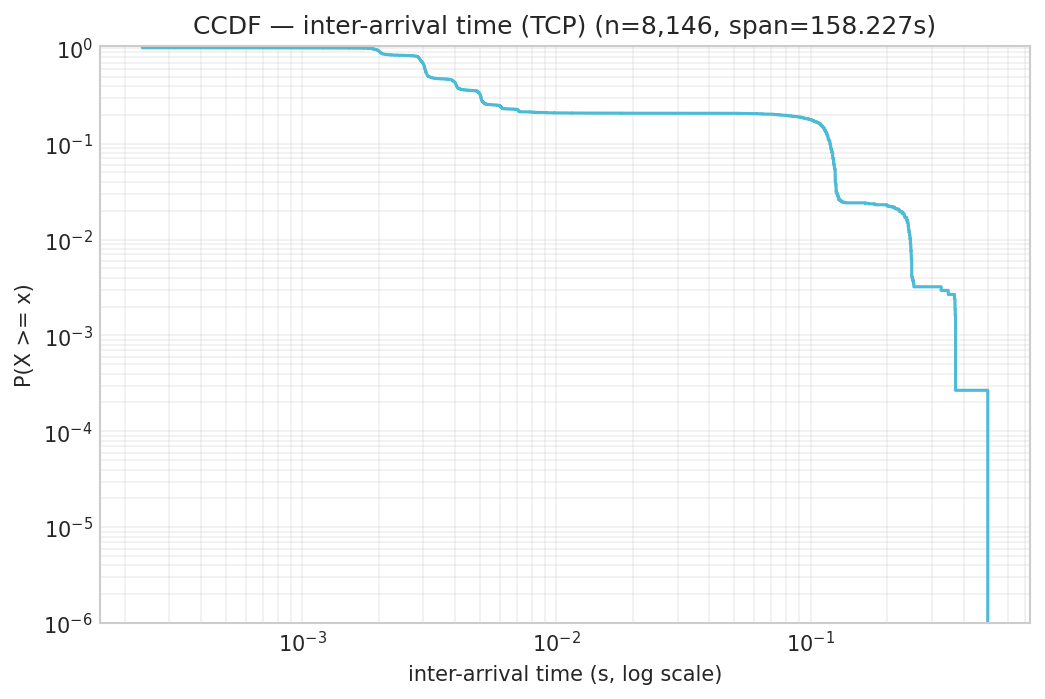

For TCP only, the CCDF keeps the same stair-step decay in Task II. Pacing stretches absolute time to ~158 s, but burst spacing within TCP is structurally unchanged. Timestamp export looks stable for the dominant protocol.

### IAT CCDF (UDP only)

`packet/distribution/iat_ccdf_udp.png`


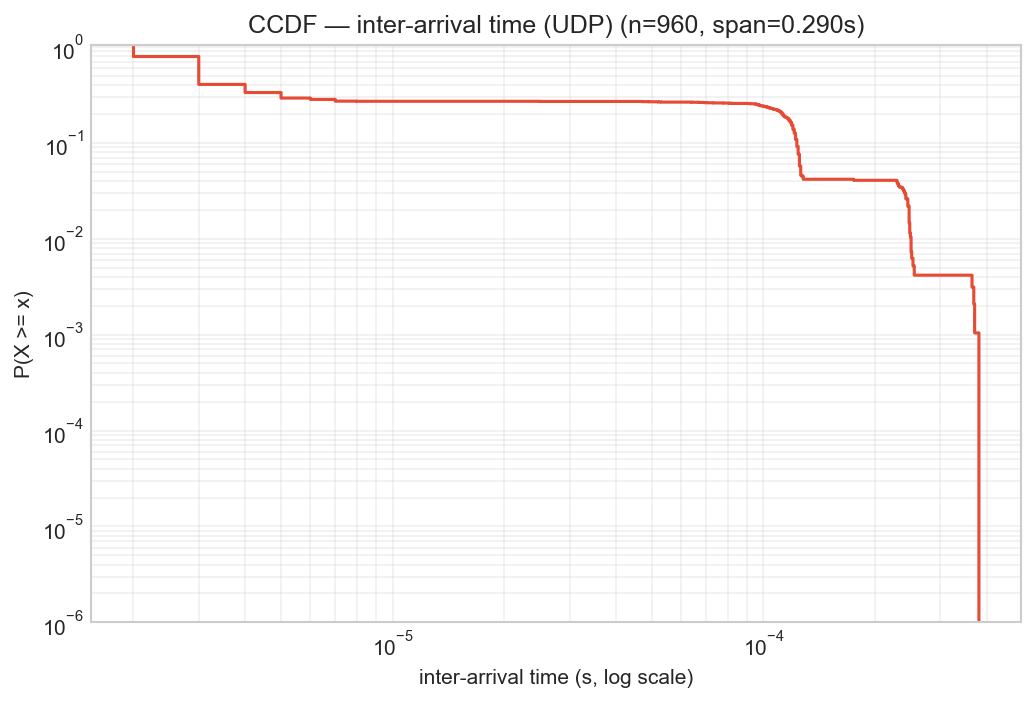
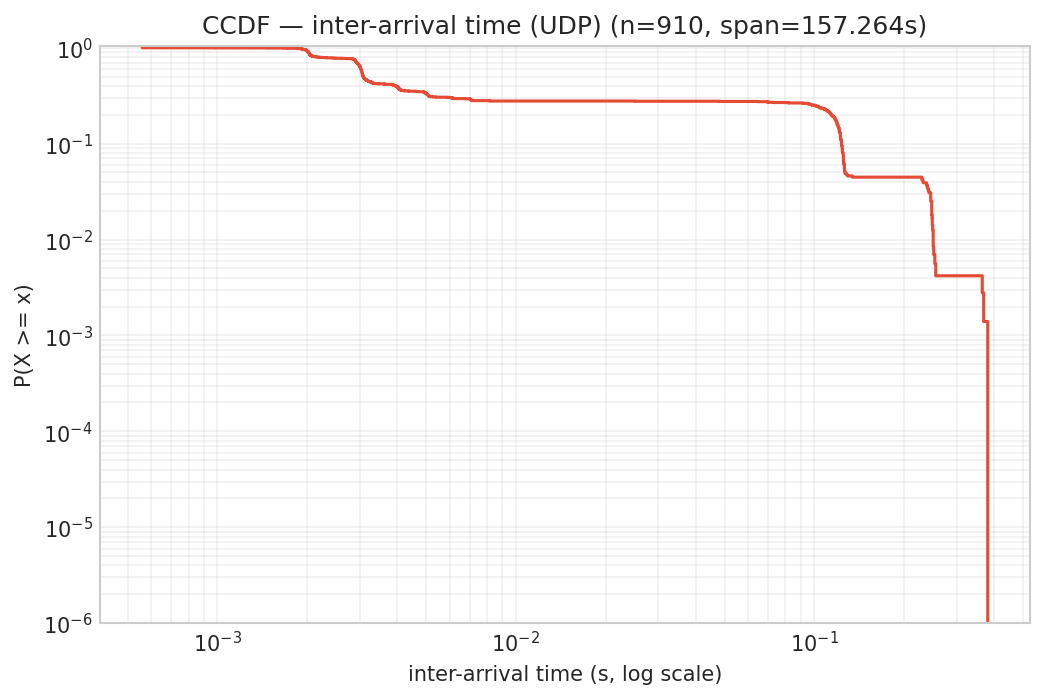

The UDP CCDF is noisier because UDP volume is smaller, but Task II preserves the relative tail of inter-packet gaps in that subset.

**Note: timestamp quantization and "missing" IAT samples**

TCP and UDP subset sizes drop slightly in Task II (e.g. UDP $n=960 \to 910$, TCP $n=8,328 \to 8,146$). The transport bar chart already showed all 10,000 packets were forwarded; this is not drop loss.

BMv2 timestamps resolve to 1 $\mu s$. Under load, back-to-back packets often share the same tick, so IAT = 0. Log-scale plots and exponential fits need IAT > 0, so `plot_common.py` drops zero-delta pairs. The smaller $n$ values count how often the emulated switch batches packets within one microsecond.

### Flow size PDF (mice)

`flow/distribution/flow_size_mice_pdf.png`


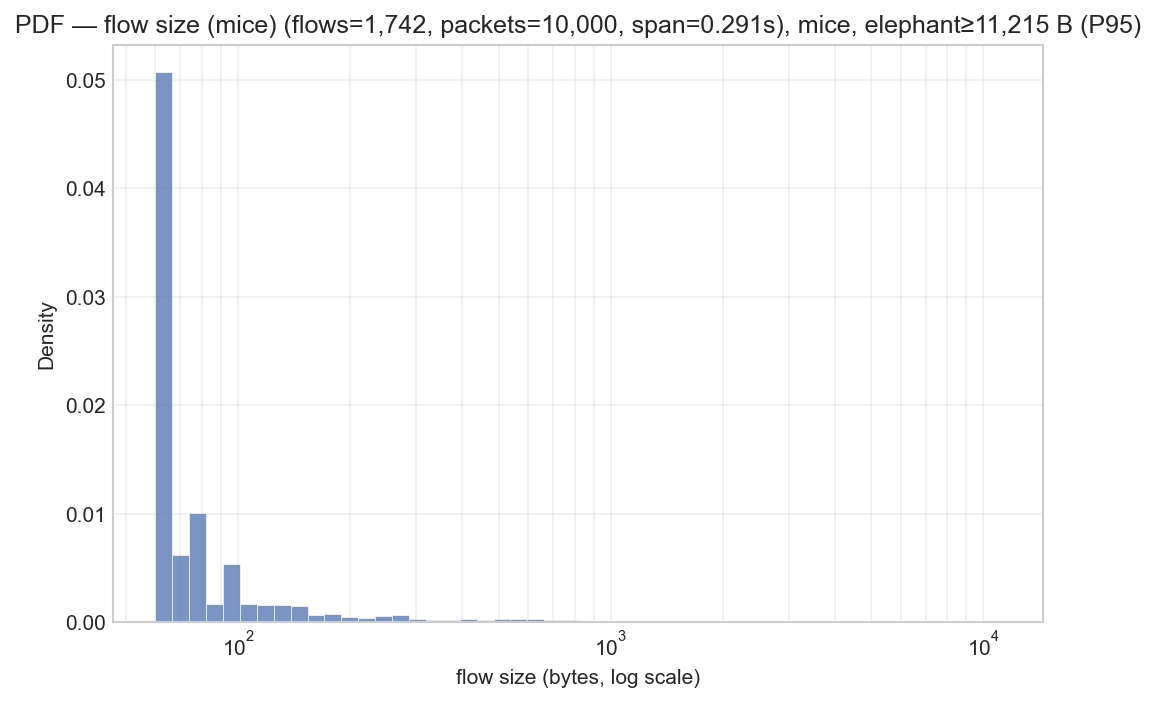
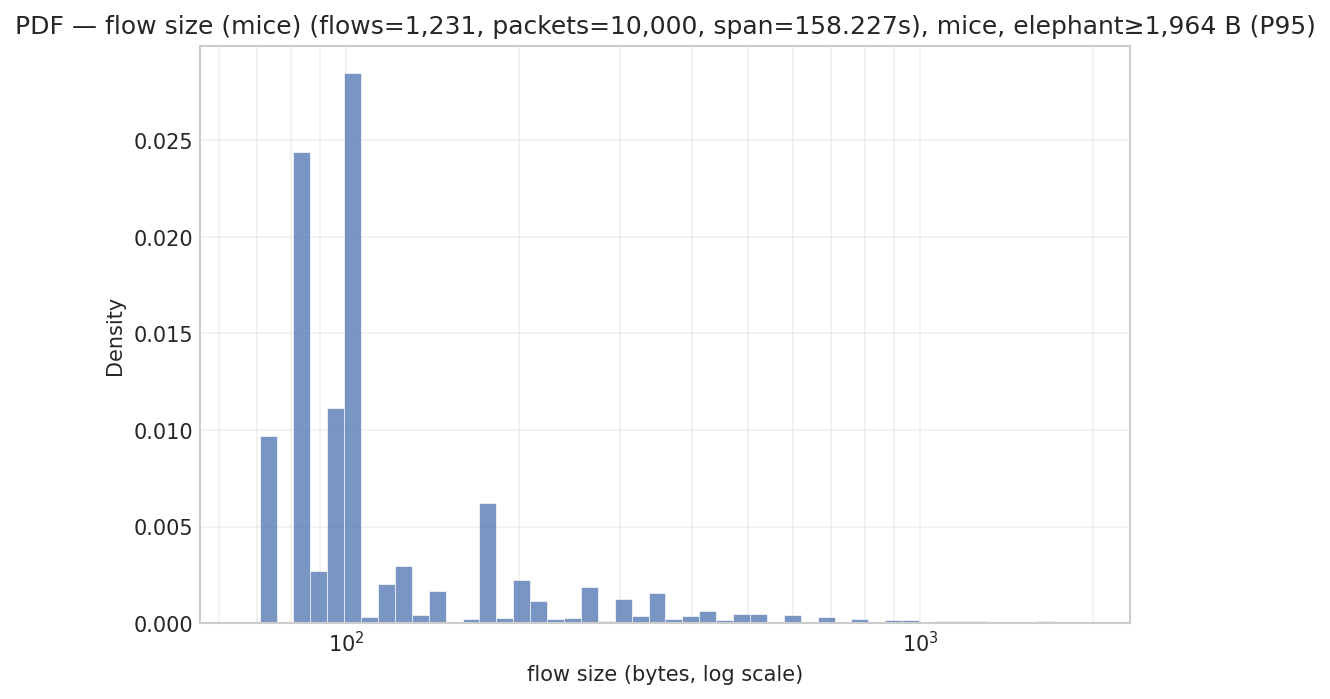

Below the P95 size cutoff, mice flows vanish from the left side of the Task II PDF. Hash collisions in the 16,384-entry table force many single-packet flows into slots already used by larger flows, so micro-flows drop out of the record and elephant bins pick up extra bytes.

### Flow size PDF (elephant)

`flow/distribution/flow_size_elephant_pdf.png`


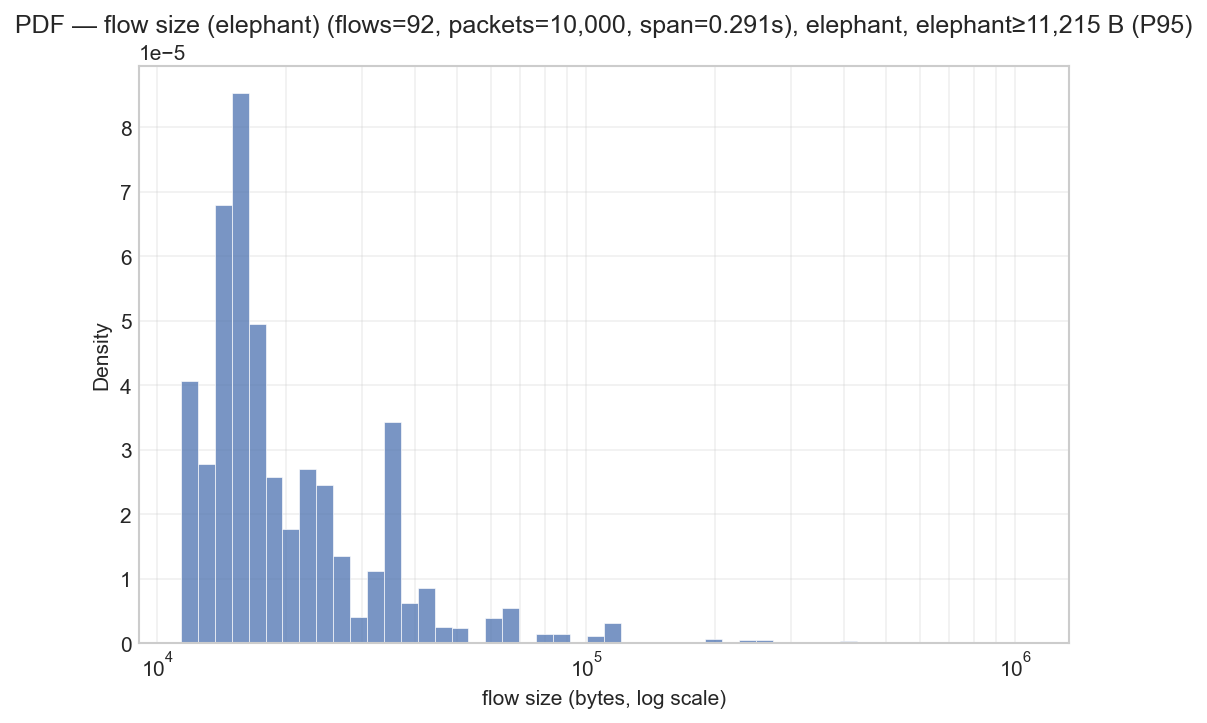
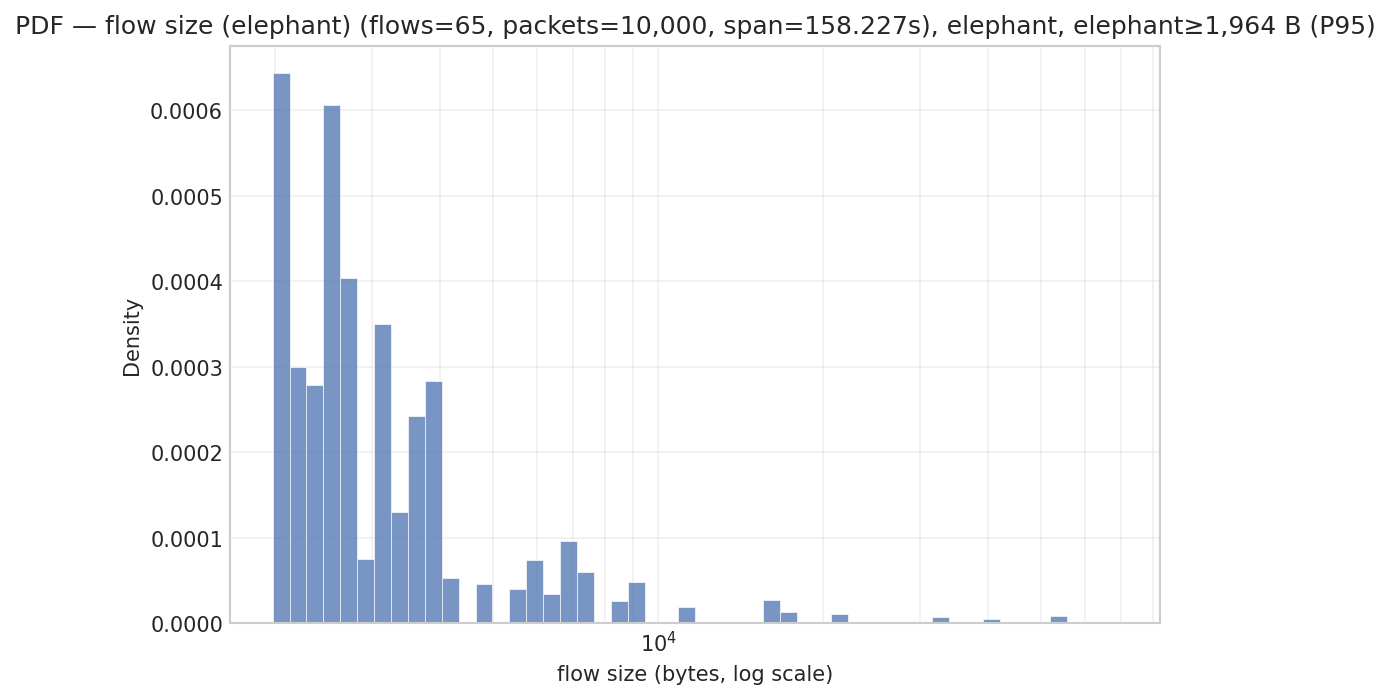

Above the P95 cutoff, Task II elephant flows show inflated byte totals when colliding micro-flows merge into their register slots. Snaplen truncation also caps per-frame bytes, so the absolute scale compresses even where the heavy tail remains.

**Note: P95 size boundary (mice vs elephant split)**

The P95 size cut falls from **11,215 B** (Task I) to **1,964 B** (Task II) for two reasons. (1) **Snaplen:** tshark reports original lengths; Task II counts truncated replay frames (~96 B). (2) **Hash loss:** over 500 micro-flows disappeared from registers, shrinking the population and pulling the percentile down. Truncation and aliasing move the mice/elephant boundary together.

### Flow duration PDF (mice)

`flow/distribution/flow_duration_mice_pdf.png`


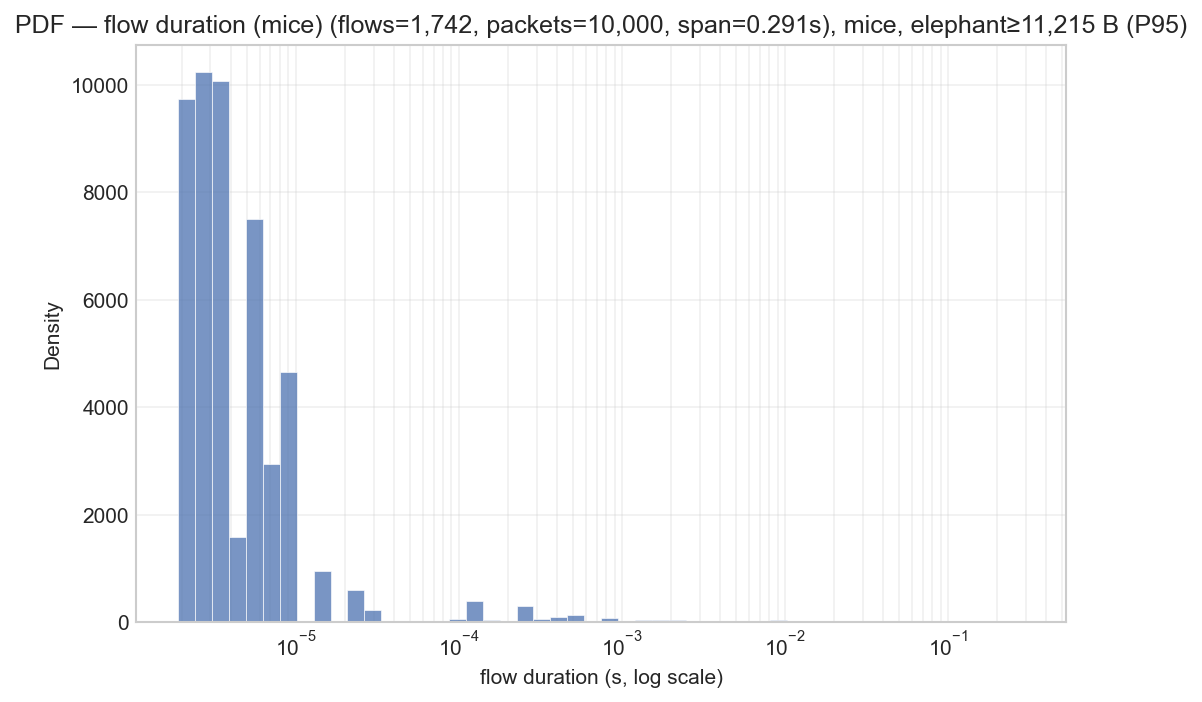
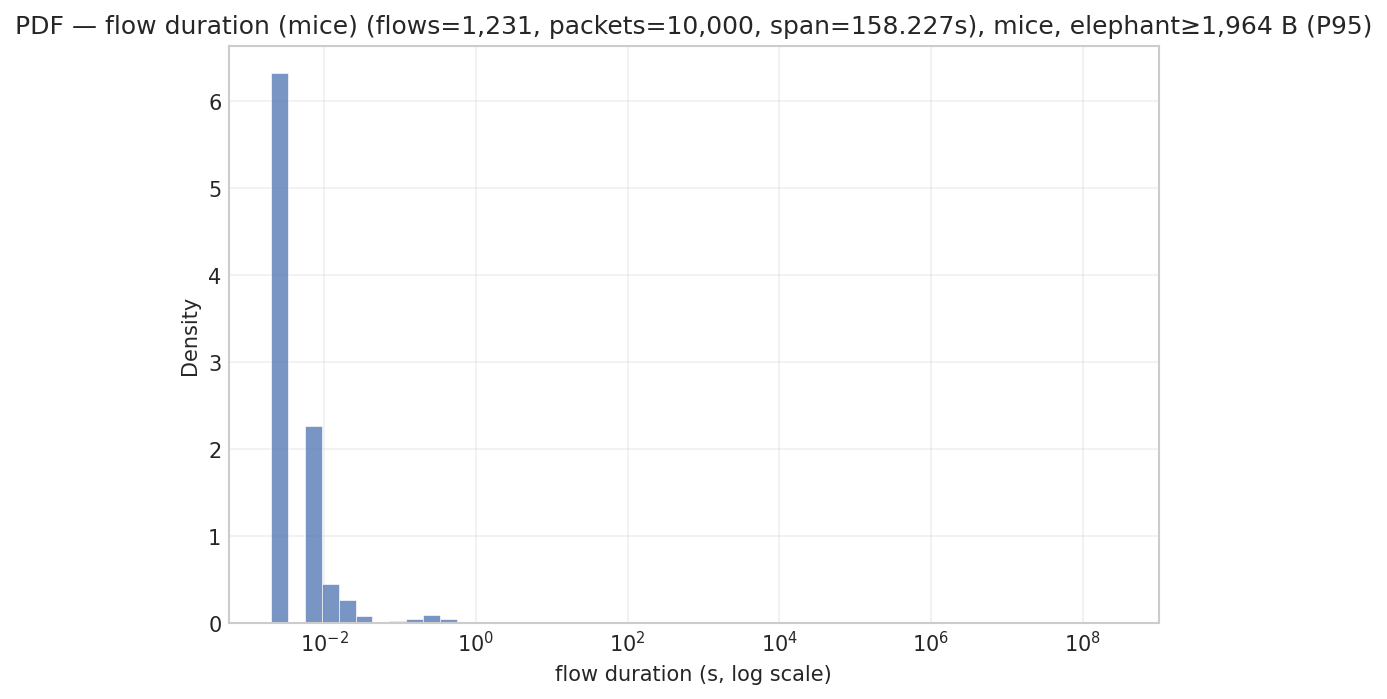

For mice flows, Task I clusters durations below $10^{-5}$ s. Task II spreads the same class across the plot up to $10^8$ (microsecond registers plotted as seconds) with very low peak density.

Single-packet mice that collide into long-lived register slots inherit those slots' `last_timestamp - first_timestamp` span. Aliasing inflates elephant byte counts and also wipes out the short lifetime signature of mice.

### Flow duration PDF (elephant)

`flow/distribution/flow_duration_elephant_pdf.png`


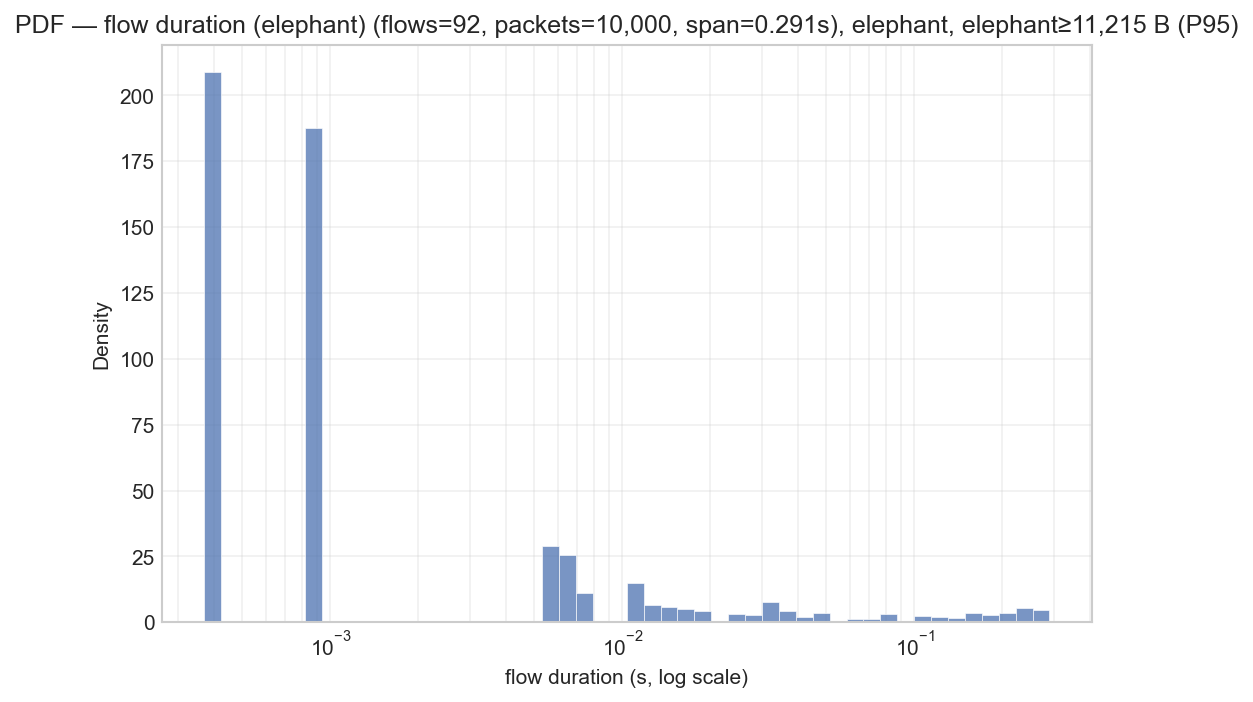
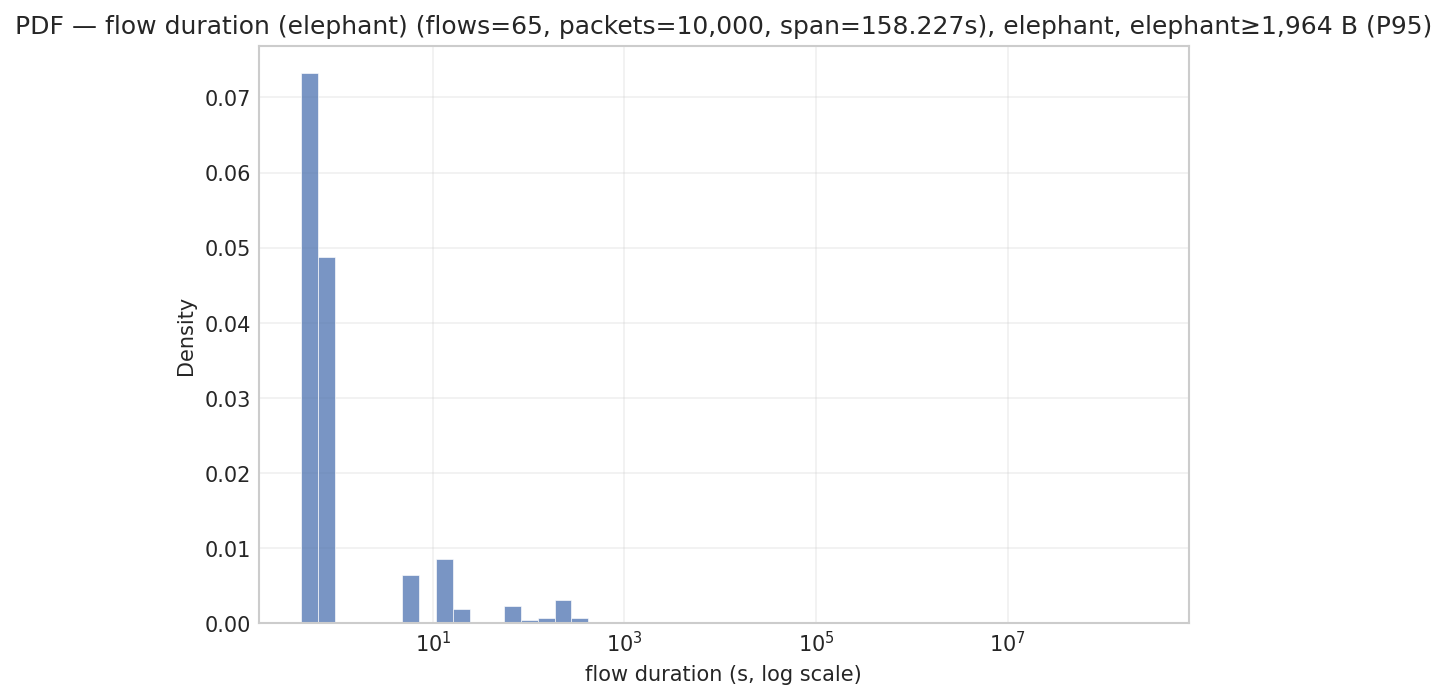

For elephant flows, Task II spreads duration mass toward the full 158 s capture window. Long-lived hash slots keep updating `last_timestamp`, so true elephants and aliased traffic both appear as multi-second or full-window flows.

Stateful metrics (size, duration, throughput) are the most distorted outputs here. Stateless packet counts and ingress timestamps are more reliable at line rate; complex flow state belongs in an off-switch control plane with unbounded memory.

In [5]:
compare(
    "packet/distribution/iat_ccdf_tcp.png",
    "IAT CCDF (TCP only)",
    note=(
        "For TCP only, the CCDF keeps the same stair-step decay in Task II. Pacing stretches absolute "
        "time to ~158 s, but burst spacing within TCP is structurally unchanged. Timestamp export "
        "looks stable for the dominant protocol."
    ),
)

compare(
    "packet/distribution/iat_ccdf_udp.png",
    "IAT CCDF (UDP only)",
    note=(
        "The UDP CCDF is noisier because UDP volume is smaller, but Task II preserves the relative "
        "tail of inter-packet gaps in that subset."
    ),
)

display(Markdown(
    "**Note: timestamp quantization and \"missing\" IAT samples**\n\n"
    "TCP and UDP subset sizes drop slightly in Task II (e.g. UDP $n=960 \\to 910$, TCP "
    "$n=8,328 \\to 8,146$). The transport bar chart already showed all 10,000 packets were "
    "forwarded; this is not drop loss.\n\n"
    "BMv2 timestamps resolve to 1 $\\mu s$. Under load, back-to-back packets often share the same "
    "tick, so IAT = 0. Log-scale plots and exponential fits need IAT > 0, so `plot_common.py` drops "
    "zero-delta pairs. The smaller $n$ values count how often the emulated switch batches packets "
    "within one microsecond."
))

compare(
    "flow/distribution/flow_size_mice_pdf.png",
    "Flow size PDF (mice)",
    note=(
        "Below the P95 size cutoff, mice flows vanish from the left side of the Task II PDF. "
        "Hash collisions in the 16,384-entry table force many single-packet flows into slots "
        "already used by larger flows, so micro-flows drop out of the record and elephant bins "
        "pick up extra bytes."
    ),
)

compare(
    "flow/distribution/flow_size_elephant_pdf.png",
    "Flow size PDF (elephant)",
    note=(
        "Above the P95 cutoff, Task II elephant flows show inflated byte totals when colliding "
        "micro-flows merge into their register slots. Snaplen truncation also caps per-frame bytes, "
        "so the absolute scale compresses even where the heavy tail remains."
    ),
)

display(Markdown(
    "**Note: P95 size boundary (mice vs elephant split)**\n\n"
    "The P95 size cut falls from **11,215 B** (Task I) to **1,964 B** (Task II) for two reasons. "
    "(1) **Snaplen:** tshark reports original lengths; Task II counts truncated replay frames "
    "(~96 B). (2) **Hash loss:** over 500 micro-flows disappeared from registers, shrinking the "
    "population and pulling the percentile down. Truncation and aliasing move the mice/elephant "
    "boundary together."
))

compare(
    "flow/distribution/flow_duration_mice_pdf.png",
    "Flow duration PDF (mice)",
    note=(
        "For mice flows, Task I clusters durations below $10^{-5}$ s. Task II spreads the same class "
        "across the plot up to $10^8$ (microsecond registers plotted as seconds) with very low peak "
        "density.\n\n"
        "Single-packet mice that collide into long-lived register slots inherit those slots' "
        "`last_timestamp - first_timestamp` span. Aliasing inflates elephant byte counts and also "
        "wipes out the short lifetime signature of mice."
    ),
)

compare(
    "flow/distribution/flow_duration_elephant_pdf.png",
    "Flow duration PDF (elephant)",
    note=(
        "For elephant flows, Task II spreads duration mass toward the full 158 s capture window. "
        "Long-lived hash slots keep updating `last_timestamp`, so true elephants and aliased traffic "
        "both appear as multi-second or full-window flows.\n\n"
        "Stateful metrics (size, duration, throughput) are the most distorted outputs here. "
        "Stateless packet counts and ingress timestamps are more reliable at line rate; complex "
        "flow state belongs in an off-switch control plane with unbounded memory."
    ),
)


---
### Experimental Limitations

The comparison runs in BMv2 + Mininet, not on production ASIC hardware. Much of the Task I vs Task II gap comes from the emulation setup.

* **Emulation environment:** BMv2 adds software switching delay. Replay at `REPLAY_MULTIPLIER=0.001` stretches inter-arrival times by about 500× relative to the original MAWI wire timeline. Timestamps are in microseconds ($\mu s$), so sub-microsecond structure is not available.
* **Data-plane memory and parsing:** The 16,384-slot CRC16 flow table causes hash aliasing (1,834 flows in Task I vs 1,296 in Task II). The P4 parse graph plus L4 port heuristics do not match tshark dissection for GRE, ICMPv6, and similar cases, which inflates the `unknown` application bucket in Task II.
* **Payload truncation and derived metrics:** MAWI uses ~96-byte snaplen. Task I can still report original L2 lengths from PCAP metadata; replay injects truncated frames, so byte totals compress on the wire. Hash aliasing lengthens flow durations; throughput ($\text{bytes} / \text{duration}$) inherits both errors.
* **Export overhead:** In-band telemetry adds a 32-byte trailer on every forwarded frame and shifts frame-length plots. A UDP INT clone trial lost ~8.6% of records (9,136 of 10,000) under BMv2 load; the main figures use live in-band capture instead.


---
### Architectural Evaluation

Task I (offline tshark) vs Task II (P4 telemetry replay) on four points:

**1. Accuracy**

Task I keeps exact 5-tuple flows and full dissection. Task II is reliable for stateless per-packet timing (IAT burst shapes survive replay pacing). Stateful metrics degrade: hash aliasing, fewer distinct flows, and port-only app labels.

**2. Overhead**

Task I adds no in-band bytes but heavy offline CPU. Task II pays on the wire (32-byte in-band trailer) or in the pipeline (UDP INT cloning). Clone export cost ~8.6% packet loss in our trial (This packet loss will likely be elimnated in physical switches).

**3. Scalability**

Full capture plus tshark dissection at line rate does not scale to multi-100 Gbps links. Per-packet register updates in P4 are $O(1)$ at forwarding time, but a fixed 16K flow table does not scale with concurrent flow fan-out.

**4. Ease of implementation**

Task I: `tshark` export and a Python analysis pipeline. Task II: P4 program, P4Runtime/gRPC reset and export setup, and a host collector to parse trailers and rebuild timelines from exported IAT, which is much harder to implement.


---
### Conclusion

Moving observability into P4 changes what is measured, not just where the code runs. Task I and Task II agree where the metric is stateless: transport mix, raw counters, and relative IAT burst shape (after replay pacing). They diverge on exact flow state and derived quantities.

Inside the switch, hash collisions merge distinct 5-tuples, remove many micro-flows, and inflate bytes on occupied elephant slots. Truncated replay frames and microsecond timestamps stretch durations into multi-second ghost flows; throughput derived from those inputs collapses on Task II.

Use the data plane for line-rate sketches (timestamps, byte counters, headers or samples). Resolve 5-tuple identity, flow duration, and rate calculation on the control plane with exact keys and enough memory to hold flow state.
